# Cluster analysis with K-means

Algorisme de l'article [Spectral-clustering approach to Lagrangian vortex detection](https://arxiv.org/pdf/1506.02258) a partir de trajectòries del sistema dinàmic donat 
pel següent sistema d'EDOs:  $x'=y + \epsilon f(t)$,  $y'=x-x^3$, on $f(t)=sin(t)$.

In [72]:
import sys
sys.path.append("..")
from src import *
import numpy as np
np.set_printoptions(precision=3, suppress=True)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Paràmetres

In [73]:
epsilon = 0
funcio_soroll = np.sin
dimensio = 2
t_span = (0, 4*np.pi)
t_steps = 300
t_valors = np.linspace(t_span[0], t_span[1], t_steps)
x_min, x_max = (-1.6, 1.6)
y_min, y_max = (-1, 1)
espai_entre_punts = 0.05
constant_diagonal = 100000
max_clusters = 10

### 1. Generar $n$ posicions inicials aleatòries

In [74]:
condicions_inicials = generar_condicions_inicials(
    espai_entre_punts, (x_min, x_max), (y_min, y_max)
)
num_trajectories = len(condicions_inicials)

Nombre de trajectòries = 2665 = 41 files * 65 columnes


In [75]:
# grafica_punts(condicions_inicials, dibuixa_regions=False)

### 2. Generar $n$ trajectòries, una per a cada posició inicial

In [76]:
trajectories = generar_trajectories(edo_duffing, condicions_inicials, t_span, t_valors)
print("(Num trajectories, t_steps, dimensio) =", trajectories.shape)

(Num trajectories, t_steps, dimensio) = (2665, 300, 2)


In [77]:
# grafica_trajectories(trajectories, dibuixa_regions=False)

In [78]:
exemples = np.array((trajectories[0], trajectories[1165], trajectories[1323]))
# grafica_trajectories(exemples)

### 3. Calcular distàncies $r_{ij}$ entre trajectòries i crear graf $G = (V, E, W)$

Els vèrtexs són cadascuna de les $n$ trajectòries: $V=\{v_1,...,v_n\}$.

Cada aresta $e_{ij}\in E\subseteq V\times V$ està associada al pes $w_{ij}\in W\in\R^{n\times n}$, on $W$ és la matriu de similaritat i $w_{ij} = 1/r_{ij}$. Cada pes representa quant de properes són dues trajectòries ($0 \rightarrow$ poc, i $\infty \rightarrow$ molt).

### 4 Matriu de similaritat

In [79]:
matriu_pesos = calcula_matriu_pesos(trajectories)

In [80]:
# imprimeix_estadistics(matriu_pesos)

##### 4.1 Opció A: triar radi d'esparsificació tal que el 95% de la matriu de pesos es torni nul·la

In [142]:
matriu_similaritat_W, sparsification_tol, sparsification_percent = \
    sparcify(matriu_pesos, percent=90)
print(f"S'ha obtingut una esparsificació del "
      f"{sparsification_percent*100:.0f}% usant una tolerància de "
      f"{sparsification_tol:.3f}")
np.fill_diagonal(matriu_similaritat_W, constant_diagonal)
# print(matriu_similaritat_W)

S'ha obtingut una esparsificació del 90% usant una tolerància de 1.307


##### Opció B: triar radi d'esparsificació que maximitza la diferència màxima entre VAPs consecutius

Radi: 0.302, Esparsificació: 0.00%, Clusters: 19, Max Eigen gap: 1.62130e-04


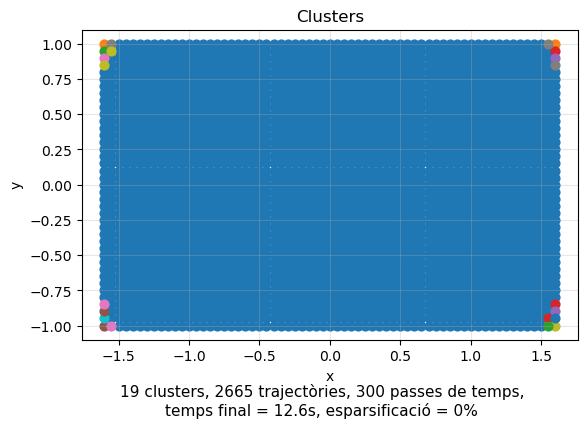

Radi: 0.679, Esparsificació: 44.15%, Clusters: 3, Max Eigen gap: 3.05050e-04


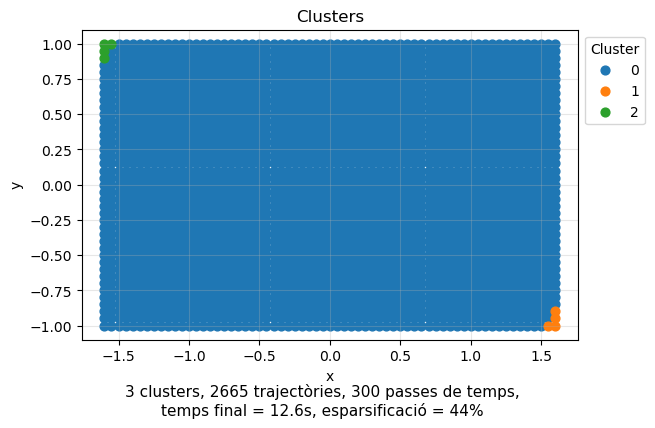

Radi: 1.056, Esparsificació: 85.21%, Clusters: 17, Max Eigen gap: 1.03548e-04


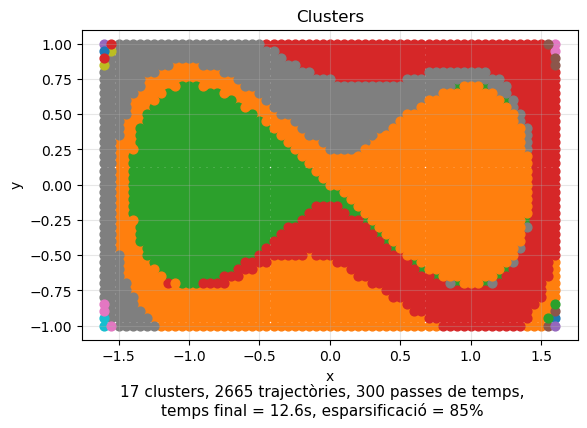

Radi: 1.433, Esparsificació: 91.73%, Clusters: 7, Max Eigen gap: 1.11467e-04


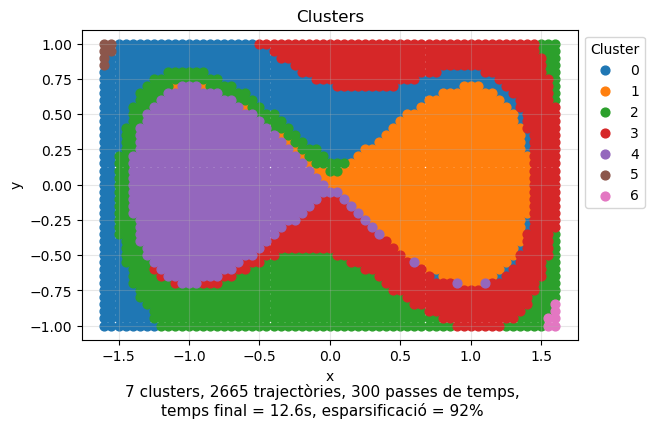

Radi: 1.791, Esparsificació: 95.00%, Clusters: 10, Max Eigen gap: 5.34829e-05


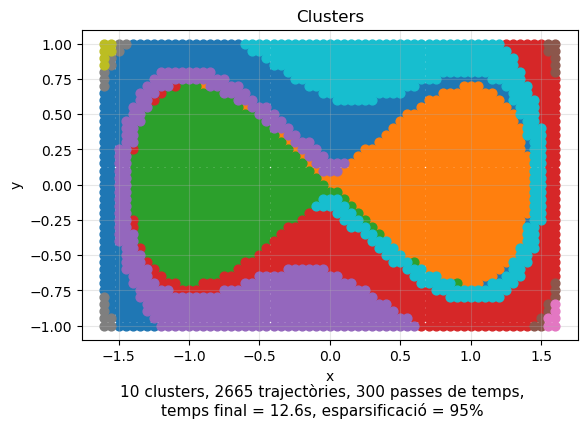

In [133]:
plot_args = calcula_diffs_vs_radis(matriu_pesos, constant_diagonal, condicions_inicials, t_steps, t_span)
diffs, nums_clusters, radis, estadistics, sparsificacions = plot_args

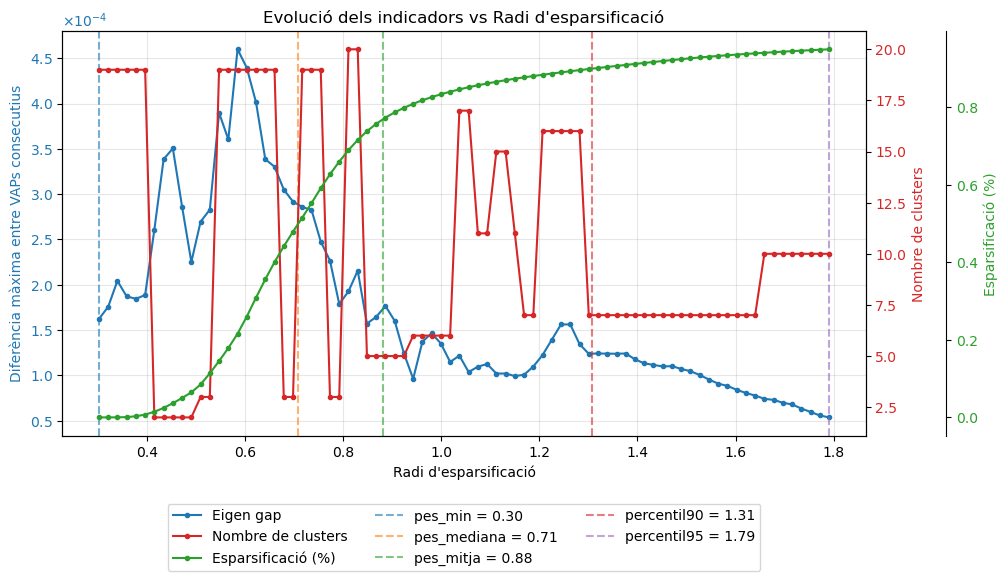

In [141]:
grafica_eigengaps_vs_radi(diffs, nums_clusters, radis, estadistics, sparsificacions)

### 6. Descomposició espectral: $Lu =\lambda Du$, on la matriu diagonal de graus $D$ és $D_{ii}=\sum _{j=0}^{n} w_{ij}$.

In [143]:
vaps, veps = calcula_vaps(matriu_similaritat_W, max_clusters)
print("vaps =", vaps)
print("veps.shape =", veps.shape)

vaps = [-0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
veps.shape = (2665, 11)


### 7. Estimació del nombre de clústers $k$ = argmin [max($g_i$)]

In [144]:
num_clusters, diff_max = calcula_num_clusters_i_max_eigengap(vaps)
print("nombre de clusters =", num_clusters)
print("màxima diferència de VAPs consecutius =", diff_max)

nombre de clusters = 7
màxima diferència de VAPs consecutius = 0.0001252710635341868


### 8. $k$-means

In [150]:
labels = troba_clusters(num_clusters, veps)

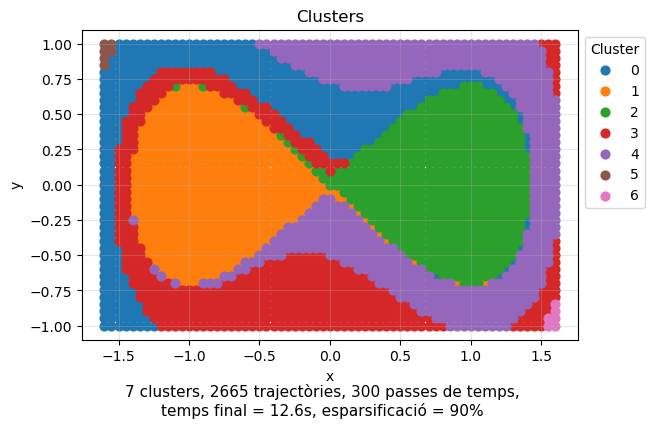

In [149]:
grafica_clusters(condicions_inicials, labels, num_clusters, sparsification_tol, sparsification_percent, t_steps, t_span)